In [14]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters, solvers
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(solvers);

---

In [126]:
N = 100; M = 100;
dt = 1/N; beta = 2.0; noise_scale = np.sqrt(2.0*dt/(beta*N))
total_crossed = 0

x_init = random_matrix.init_gue_eigenvalues(M, N)
noise = np.random.normal(0, 1, x_init.shape)
z = x_init + noise_scale*noise

for m in range(M):
    for i in range(N - 1):
        starting_crossed = z[m, i + 1] - z[m, i] < 0
        if (starting_crossed):
            total_crossed += 1
            break

total_crossed/M

0.99

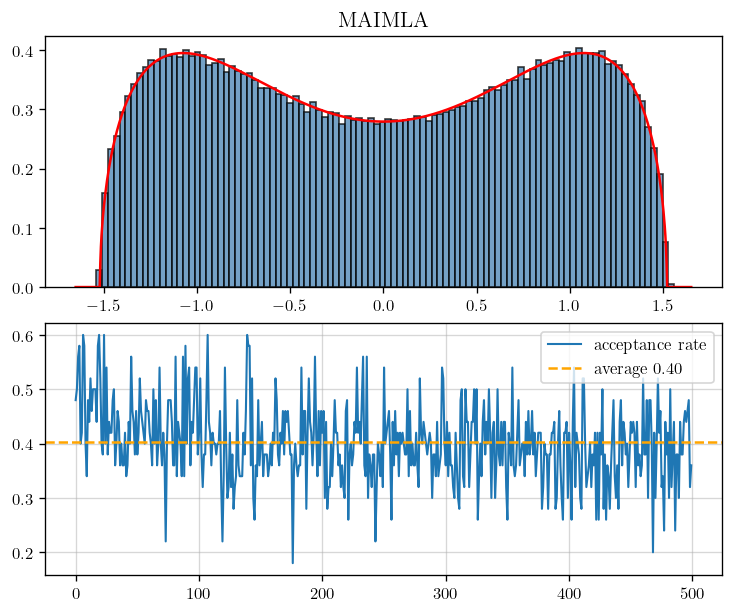

Mean Newton iterations: 5.39684
Mean CG iterations: 9.643824006771007
Mean rejects due to line search failure: 0.19528000000000004


In [142]:
# MAIMLA EXAMPLE
importlib.reload(integrators); importlib.reload(simulate); importlib.reload(solvers);

# Set hyperparameters.
N = 100; dt = 1/N; beta = 2.0; T = 5.0;
M = 50; potential_name = "quartic"
total_steps = int(T/dt)

# Initialise as random, for example.
init = random_matrix.init_gue_eigenvalues(M, N)

# Build a MAIMLA pipeline and get trajectory generator.
maimla_pipe = simulate.make_imla_pipeline(N, dt, potential_name, beta, metropolise = True)
trajectory = simulate.simulate_dbm(init, total_steps, maimla_pipe)

# Decide on experiment configuration and call the observe function in `simulate.py`.
config = {
    "track_accepts": True,
    "burn_in": int(2.5/dt),
    "track_newton_info": True
}

info = simulate.analyse_trajectory(trajectory, total_steps, **config)

# Example plots for snapshots and acceptance rates.
fig, axes = plt.subplots(2, 1, figsize = (6, 5))
ax, ax2 = axes

plotters.plot_hist(ax, info["snapshots"], num_bins = 100, potential_name = potential_name)
plotters.plot_accepts(ax2, info["accepts"])

ax.grid(False)
ax.set_title(f"MAIMLA")

plt.show()

print(f"Mean Newton iterations: {info["newton_iters"].mean()}")
print(f"Mean CG iterations: {info["mean_cg_iters"].mean()}")
print(f"Mean rejects due to line search failure: {info["line_search_rejects"].mean()}")

#### Jacobi CG test.

In [54]:
N = 100
importlib.reload(solvers);

# Random symmetric matrix.
A = np.random.rand(N, N); A = (A + A.T) / 2.0 
np.fill_diagonal(A, np.sum(np.abs(A), axis = 1) + np.random.uniform(0, 1)) # SDD
b = np.random.rand(N)

exact_step = np.linalg.solve(A, b)
cg_step, cg_iters = solvers.cg_jacobi(A, b)

error = np.max(np.abs(exact_step - cg_step))
print(f"Max absolute error: {error:.2e}")
print(f"Iterations taken: {cg_iters} (Should be <= {N}).")

Max absolute error: 1.48e-12
Iterations taken: 8 (Should be <= 100).
